In [2]:
import pennylane as qml
import numpy as np

In [59]:
# Build a device
# Size of the Sudoku:
size = 2
# need ceil(log2(size)) qubits per grid, and 3 ancilla so...
m = int(2**(np.log2(size)-1)*size**2)
n = m + 5
print(n)
dev = qml.device("default.qubit",n+1)

9


In [60]:
# Transfer a Sudoku setup to initial states
def process_initial_state(sudoku):
    for i,row in enumerate(sudoku):
        for j,item in enumerate(row):
            if item == 0:
                pass
            elif item == 1:
                qml.X(i*size+j+1)
            else:
                qml.H(i*size+j+1)
                

In [61]:
# Grover iteration
def grover_iteration():
    # check_rows(size)
    # check_cols(size)
    # check_boxes()
    # qml.MultiControlledX([i+1 for i in range(m)]+[n])
    checks()
    diffusion(m)

In [62]:
# Sudoku constraints
# def check_rows(size,last_result,ancilla):
#     for i in range(size):
#         for j in range(size):
#             qml.CX([i*size+j+1,ancilla])
def checks():
    qml.CNOT([1,5])
    qml.CNOT([2,5])
    #===============
    qml.CNOT([3,6])
    qml.CNOT([4,6])
    #===============
    qml.CNOT([1,7])
    qml.CNOT([3,7])
    #===============
    qml.CNOT([2,8])
    qml.CNOT([4,8])
    # update result
    qml.MultiControlledX([5,6,7,8,9])
    
    
    
            

In [63]:
def diffusion(size):
    for i in range(size):
        qml.H(i+1)
    qml.MultiControlledX([i+1 for i in range(size)]+[n])
    for i in range(size):
        qml.H(i+1)

In [82]:
@qml.qnode(dev)
def sudoku_circuit(sudoku):
    process_initial_state(sudoku)
    qml.X(n)
    qml.H(n)
    grover_iteration()
    return qml.probs([1,2,3,4,9])

In [83]:
print(qml.draw(sudoku_circuit)([[0,2],[2,2]]))

1: ────╭●──────────╭●──H──────────╭●──H─┤ ╭Probs
2: ──H─│──╭●───────│─────╭●──H────├●──H─┤ ├Probs
3: ──H─│──│──╭●────│──╭●─│───H────├●──H─┤ ├Probs
4: ──H─│──│──│──╭●─│──│──│──╭●──H─├●──H─┤ ├Probs
5: ────╰X─╰X─│──│──│──│──│──│──╭●─│─────┤ │     
6: ──────────╰X─╰X─│──│──│──│──├●─│─────┤ │     
7: ────────────────╰X─╰X─│──│──├●─│─────┤ │     
8: ──────────────────────╰X─╰X─├●─│─────┤ │     
9: ──X──H──────────────────────╰X─╰X────┤ ╰Probs


In [94]:
result = sudoku_circuit([[0,2],[2,2]])
print(result)
results = qml.snapshots(sudoku_circuit)([[0,2],[2,2]])
print(results)

[0.0546875 0.0546875 0.0546875 0.0546875 0.0546875 0.0546875 0.0546875
 0.0546875 0.0546875 0.0546875 0.0546875 0.0546875 0.0546875 0.0546875
 0.0546875 0.0546875 0.0078125 0.0078125 0.0078125 0.0078125 0.0078125
 0.0078125 0.0078125 0.0078125 0.0078125 0.0078125 0.0078125 0.0078125
 0.0078125 0.0078125 0.0078125 0.0078125]
{'execution_results': array([0.0546875, 0.0546875, 0.0546875, 0.0546875, 0.0546875, 0.0546875,
       0.0546875, 0.0546875, 0.0546875, 0.0546875, 0.0546875, 0.0546875,
       0.0546875, 0.0546875, 0.0546875, 0.0546875, 0.0078125, 0.0078125,
       0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125,
       0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125,
       0.0078125, 0.0078125])}


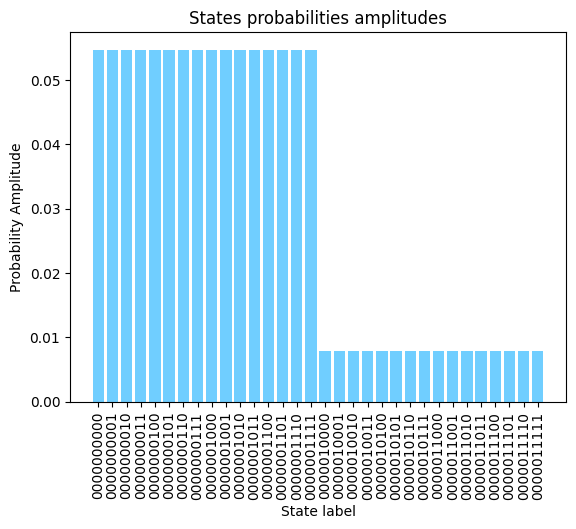

In [98]:
import matplotlib.pyplot as plt
y = np.real(results["execution_results"])
bit_strings = [f"{x:0{10}b}" for x in range(len(y))]

plt.bar(bit_strings, y, color = "#70CEFF")

plt.xticks(rotation="vertical")
plt.xlabel("State label")
plt.ylabel("Probability Amplitude")
plt.title("States probabilities amplitudes")
plt.show()